Loss: 0.1383, Accuracy: 1.0000
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 754us/step


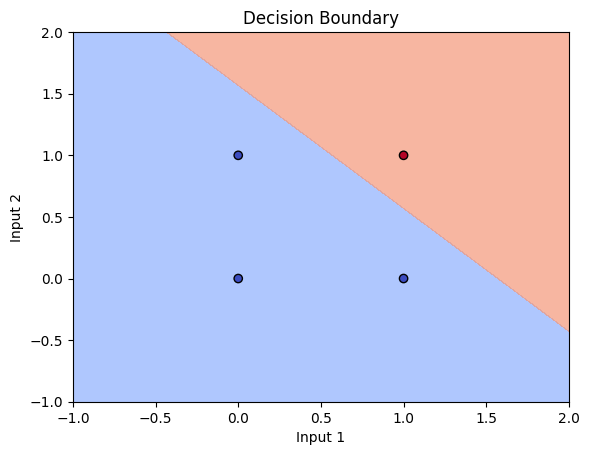

In [14]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

data = np.array([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=np.float32)
labels = np.array([[0], [0], [0], [1]], dtype=np.float32)
model = tf.keras.Sequential([tf.keras.layers.Dense(units=1, activation='sigmoid', input_shape=(2,))])

model.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.1),loss='binary_crossentropy',metrics=['accuracy'])

model.fit(data, labels, epochs=1000, verbose=0)

loss, accuracy = model.evaluate(data, labels, verbose=0)
print(f'Loss: {loss:.4f}, Accuracy: {accuracy:.4f}')

def plot_decision_boundary(model, data, labels):
    x_min, x_max = data[:, 0].min() - 1, data[:, 0].max() + 1
    y_min, y_max = data[:, 1].min() - 1, data[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max,100))
    grid = np.c_[xx.ravel(), yy.ravel()]
    predictions = model.predict(grid).reshape(xx.shape)

    plt.contourf(xx, yy, predictions, alpha=0.7, levels=[0, 0.5, 1], cmap="coolwarm")
    plt.scatter(data[:, 0], data[:, 1], c=labels[:, 0], edgecolors='k', cmap="coolwarm")
    plt.title("Decision Boundary")
    plt.xlabel("Input 1")
    plt.ylabel("Input 2")
    plt.show()
plot_decision_boundary(model, data, labels)    

Epoch 1/50


C:\Users\Sanjay A\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1200/1200 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9935 - loss: 0.0630 - val_accuracy: 0.9966 - val_loss: 0.0327
Epoch 2/50
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9960 - loss: 0.0228 - val_accuracy: 0.9966 - val_loss: 0.0292
Epoch 3/50
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9961 - loss: 0.0205 - val_accuracy: 0.9966 - val_loss: 0.0313
Epoch 4/50
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9960 - loss: 0.0165 - val_accuracy: 0.9965 - val_loss: 0.0336
Epoch 5/50
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9964 - loss: 0.0143 - val_accuracy: 0.9965 - val_loss: 0.0624
Epoch 6/50
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9967 - loss: 0.0137 - val_accuracy: 0.9966 - val_loss: 0.0465
Epoch 7/50
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9968 - loss: 0.0115 - val_accuracy: 0.9954 - val_loss: 0.0471
Epoch 8/50
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9972 - loss: 0.0094 - val_accurac

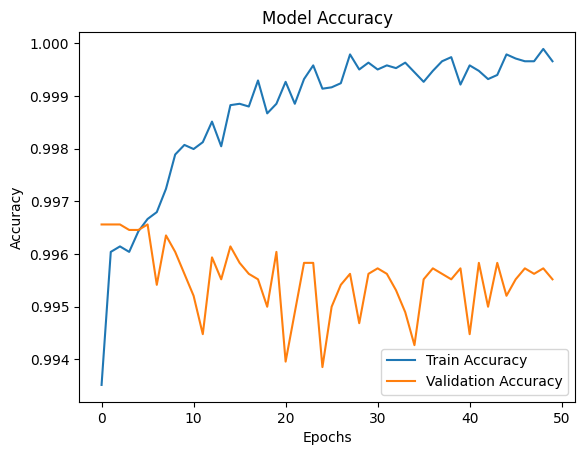

In [12]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

data = pd.read_csv('fashion-mnist_train.csv')
X = data.iloc[:, :-1].values
y = data.iloc[:, -1].values
y = tf.keras.utils.to_categorical(y)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
model = tf.keras.Sequential([tf.keras.layers.Dense(128, activation='relu', input_shape=(X_train.shape[1],))
                             ,tf.keras.layers.Dense(64, activation='relu'),tf.keras.layers.Dense(y.shape[1], activation='softmax')])
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.2,verbose=1)

loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Loss: {loss:.4f}, Test Accuracy: {accuracy:.4f}")

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Model Accuracy')
plt.legend()
plt.show()

Training model with sigmoid activation function...
Epoch 1/10


C:\Users\Sanjay A\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8210 - loss: 0.5548 - val_accuracy: 0.8553 - val_loss: 0.3974
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8698 - loss: 0.3630 - val_accuracy: 0.8729 - val_loss: 0.3574
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8856 - loss: 0.3190 - val_accuracy: 0.8750 - val_loss: 0.3419
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8954 - loss: 0.2915 - val_accuracy: 0.8753 - val_loss: 0.3367
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9040 - loss: 0.2661 - val_accuracy: 0.8786 - val_loss: 0.3280
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9120 - loss: 0.2470 - val_accuracy: 0.8842 - val_loss: 0.3201
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9186 - loss: 0.2277 - val_accuracy: 0.8839 - val_loss: 0.3290
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9242 - loss: 0.2118 - val_accurac

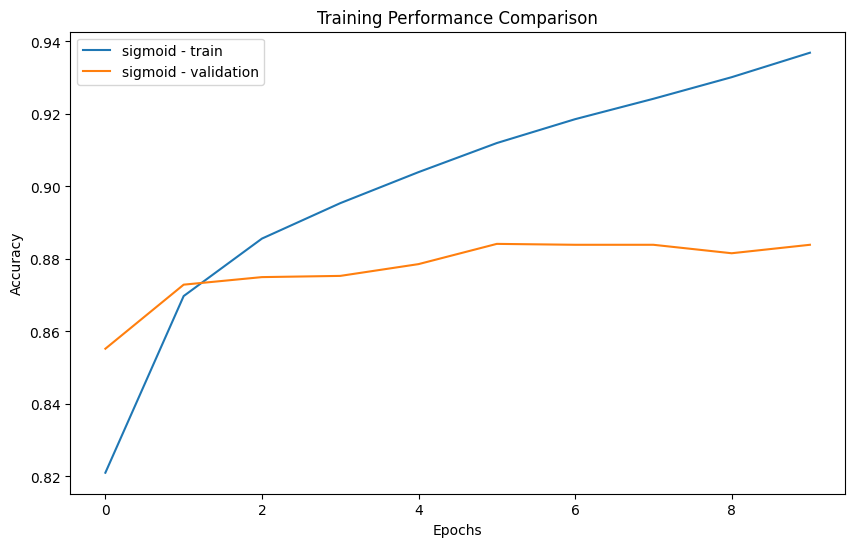

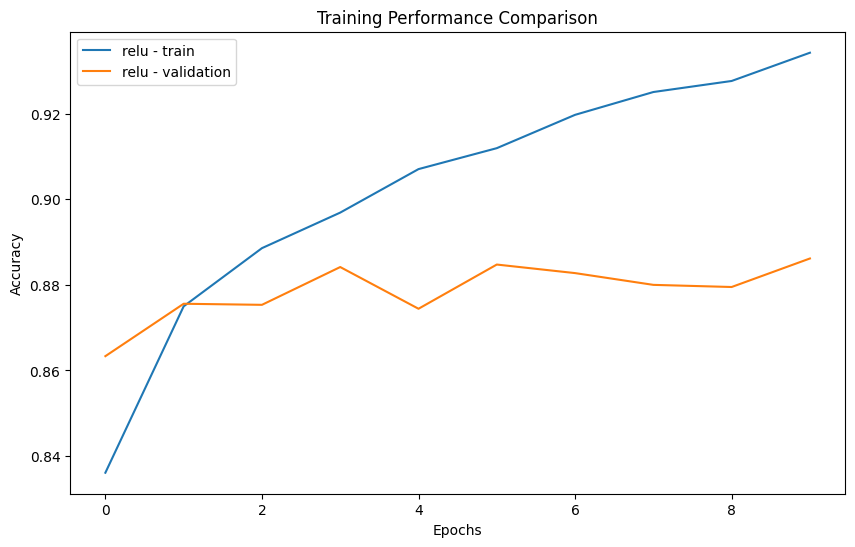

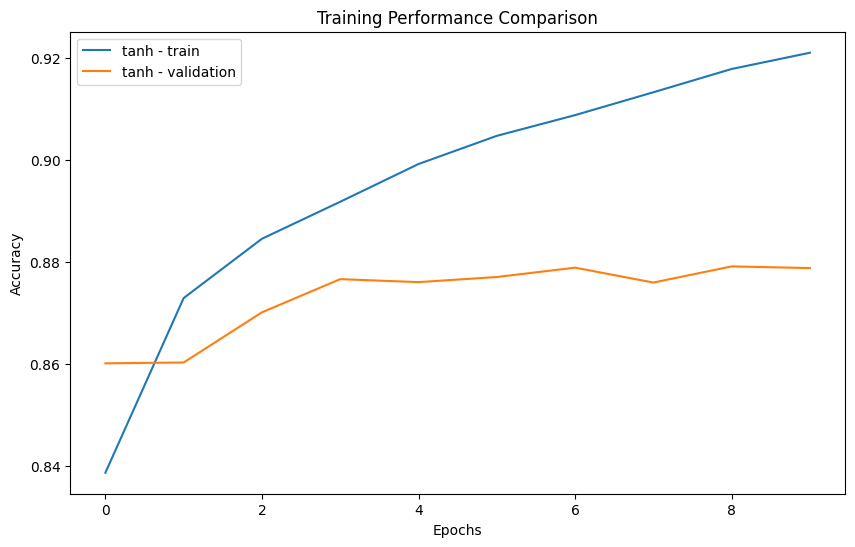

In [22]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import matplotlib.pyplot as plt

data = pd.read_csv('fashion-mnist_train.csv') # Replace with your MNIST .csv file path
X = data.drop('label', axis=1).values # Features
y = data['label'].values # Labels
scaler = StandardScaler()
X = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

def create_model(activation_function):
    model = Sequential([Dense(128, input_shape=(X_train.shape[1],), activation=activation_function),Dense(64, activation=activation_function),Dense(10, activation='softmax')])
    model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])
    return model

activation_functions = ['sigmoid','relu', 'tanh']
results = {}
for activation in activation_functions:
    print(f"Training model with {activation} activation function...")
    model = create_model(activation)
    history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_test,y_test), verbose=1)
    results[activation] = history


for activation in activation_functions:
    plt.figure(figsize=(10, 6))
    history = results[activation]
    plt.plot(history.history['accuracy'], label=f'{activation} - train')
    plt.plot(history.history['val_accuracy'], label=f'{activation} - validation')
    plt.title('Training Performance Comparison')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
plt.show()
    

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.3207 - loss: 1.9037 - val_accuracy: 0.3898 - val_loss: 1.7484
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.4406 - loss: 1.5785 - val_accuracy: 0.4751 - val_loss: 1.4798
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.5068 - loss: 1.3917 - val_accuracy: 0.5095 - val_loss: 1.3432
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.5503 - loss: 1.2824 - val_accuracy: 0.5603 - val_loss: 1.2464
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.5764 - loss: 1.2083 - val_accuracy: 0.5459 - val_loss: 1.2708
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.5980 - loss: 1.1479 - val_accuracy: 0.5873 - val_loss: 1.1712
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.6199 - loss: 1.0920 - val_accuracy: 0.5776 - val_loss: 1.2010
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.6367 - loss: 1.0419 - 

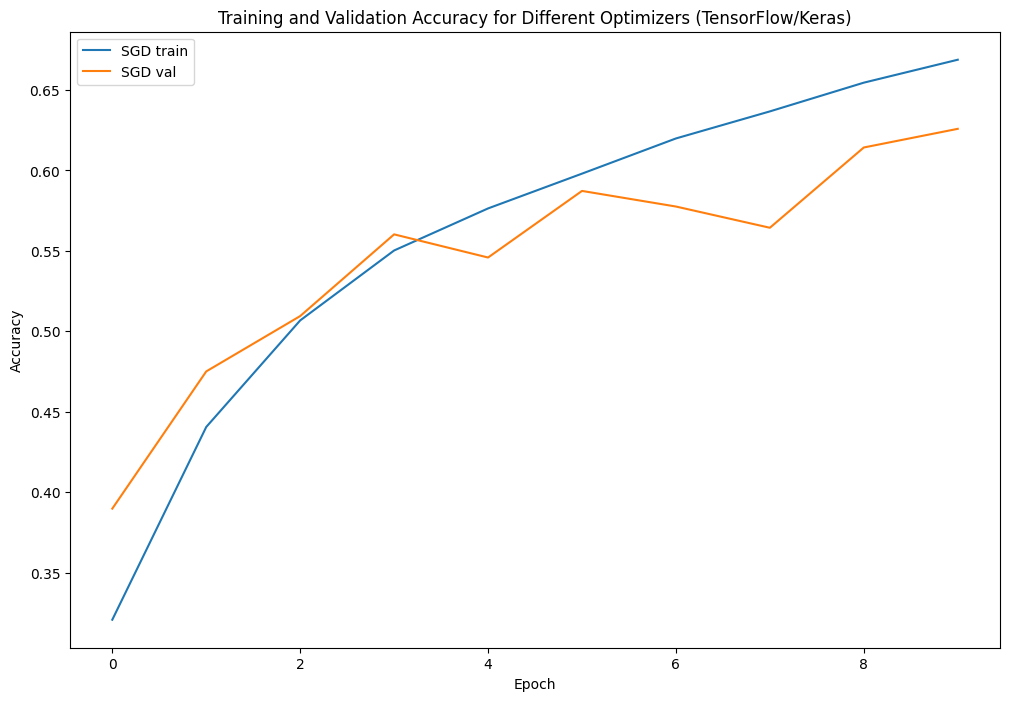

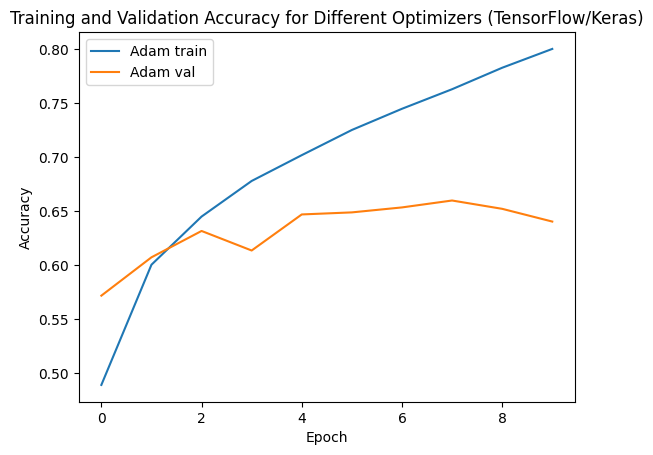

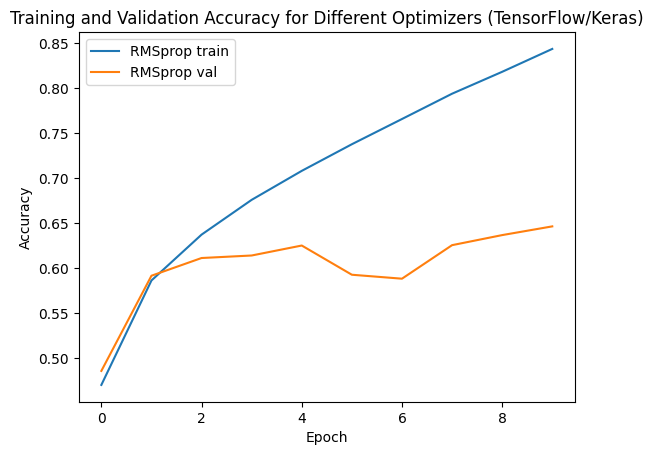

SGD - Train Accuracy: 0.6689, Validation Accuracy:0.6259
Adam - Train Accuracy: 0.8003, Validation Accuracy:0.6404
RMSprop - Train Accuracy: 0.8438, Validation Accuracy:0.6464


In [27]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.layers import Dense
import matplotlib.pyplot as plt
from tensorflow.keras.optimizers import SGD, Adam, RMSprop
from tensorflow.keras.datasets import cifar10

(X_train, y_train), (X_test, y_test) = cifar10.load_data()

X_train = X_train / 255.0
X_test = X_test / 255.0  


def build_and_train_model(optimizer, epochs=10):
    model = Sequential()
    model.add(Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(32, 32, 3)))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Flatten())   
    model.add(Dense(128, activation='relu'))
    model.add(Dense(10, activation='softmax'))
    model.compile(optimizer=optimizer,loss='sparse_categorical_crossentropy',metrics=['accuracy'])
    history = model.fit(X_train, y_train, epochs=epochs, batch_size=32, verbose=1,validation_data=(X_test, y_test))
    return history     

optimizers = {'SGD': SGD(), 'Adam': Adam(), 'RMSprop': RMSprop()}
histories = {name: build_and_train_model(optimizer) for name, optimizer in optimizers.items()}
for name in optimizers.keys():
    plt.figure(figsize=(12, 8))
    plt.plot(histories[name].history['accuracy'], label=f'{name} train')
    plt.plot(histories[name].history['val_accuracy'], label=f'{name} val')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.title('Training and Validation Accuracy for Different Optimizers (TensorFlow/Keras)')
    plt.show()
for name, history in histories.items():
    final_train_acc = history.history['accuracy'][-1]
    final_val_acc = history.history['val_accuracy'][-1]
    print(f"{name} - Train Accuracy: {final_train_acc:.4f}, Validation Accuracy:{final_val_acc:.4f}")    

C:\Users\Sanjay A\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.7507 - loss: 0.7473 - val_accuracy: 0.8419 - val_loss: 0.4879
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8141 - loss: 0.5807 - val_accuracy: 0.8538 - val_loss: 0.4685
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8234 - loss: 0.5527 - val_accuracy: 0.8615 - val_loss: 0.4444
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8299 - loss: 0.5389 - val_accuracy: 0.8663 - val_loss: 0.4419
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8322 - loss: 0.5333 - val_accuracy: 0.8669 - val_loss: 0.4309
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8368 - loss: 0.5200 - val_accuracy: 0.8706 - val_loss: 0.4204
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8394 - loss: 0.5161 - val_accuracy: 0.8734 - val_loss: 0.4193
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8405 - loss: 0.5190 - 

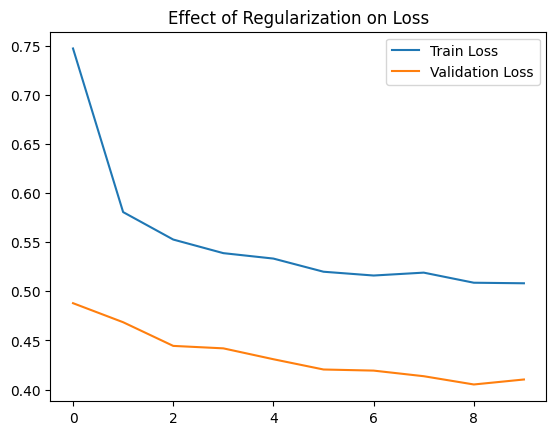

In [32]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt

train_df = pd.read_csv("fashion-mnist_train.csv")
test_df = pd.read_csv("fashion-mnist_train.csv")

train_labels = train_df.iloc[:, 0].values
train_images = train_df.iloc[:, 1:].values
test_labels = test_df.iloc[:, 0].values
test_images = test_df.iloc[:, 1:].values

train_images = train_images / 255.0
test_images = test_images / 255.0

train_images = train_images.reshape(-1, 28, 28)
test_images = test_images.reshape(-1, 28, 28)

model = keras.Sequential([
keras.layers.Flatten(input_shape=(28, 28)),
keras.layers.Dense(256, activation='relu', kernel_regularizer=keras.regularizers.l2(1e-4)),
keras.layers.Dropout(0.5), 
keras.layers.Dense(128, activation='relu', kernel_regularizer=keras.regularizers.l2(1e-4)),
keras.layers.Dropout(0.5),
keras.layers.Dense(10, activation='softmax') 
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy',
metrics=['accuracy'])

history = model.fit(train_images, train_labels, epochs=10, validation_data=(test_images,test_labels))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.legend()
plt.title("Effect of Regularization on Loss")
plt.show()


Starting Training...
Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8189 - loss: 0.4939 - val_accuracy: 0.8609 - val_loss: 0.3808
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8806 - loss: 0.3289 - val_accuracy: 0.8812 - val_loss: 0.3290
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8964 - loss: 0.2840 - val_accuracy: 0.9016 - val_loss: 0.2781
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9071 - loss: 0.2519 - val_accuracy: 0.9055 - val_loss: 0.2667
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9174 - loss: 0.2229 - val_accuracy: 0.9051 - val_loss: 0.2667

Evaluating...
Total Accuracy on Data: 0.9237
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step


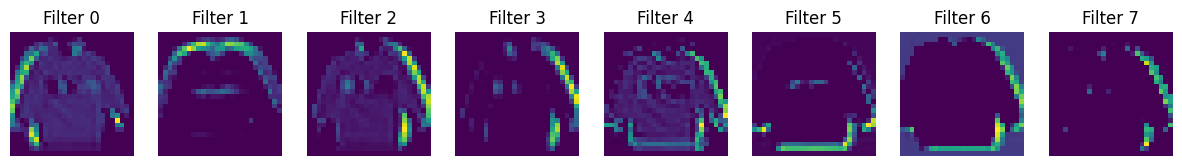

In [33]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import os

csv_path = "fashion-mnist_train.csv"


data = pd.read_csv(csv_path)
y_raw = data.iloc[:, 0].values 
X_raw = data.iloc[:, 1:].values

X = X_raw / 255.0             
X = X.reshape(-1, 28, 28, 1)    
y = keras.utils.to_categorical(y_raw, num_classes=10) 

model = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

print("\nStarting Training...")
model.fit(X, y, epochs=5, batch_size=32, validation_split=0.2)

print("\nEvaluating...")
test_loss, test_acc = model.evaluate(X, y, verbose=0)
print(f"Total Accuracy on Data: {test_acc:.4f}")


model.build(input_shape=(None, 28, 28, 1)) 

layer_outputs = [layer.output for layer in model.layers if isinstance(layer, layers.Conv2D)]


activation_model = keras.Model(inputs=model.inputs, outputs=layer_outputs)

img = X[0].reshape(1, 28, 28, 1)

activations = activation_model.predict(img)

first_layer_activations = activations[0]
num_filters = 8 
fig, axes = plt.subplots(1, num_filters, figsize=(15, 3))

for i in range(num_filters):
    axes[i].imshow(first_layer_activations[0, :, :, i], cmap='viridis')
    axes[i].axis('off')
    axes[i].set_title(f"Filter {i}")

plt.show()

C:\Users\Sanjay A\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(



Starting training...
Training Complete.


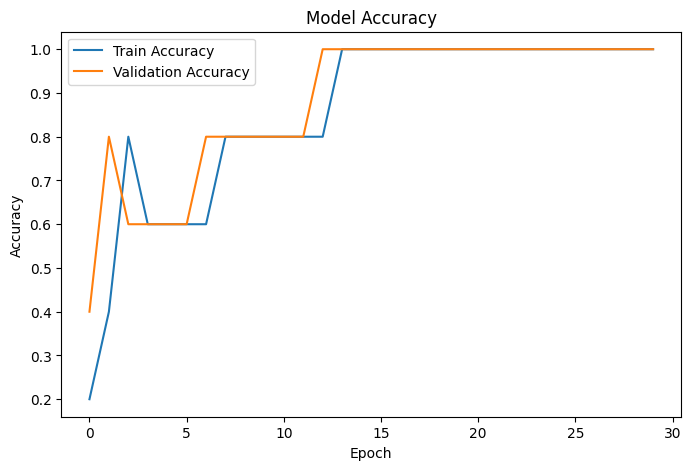


Predictions:
Text: The movie was bad bad bad, I will not recommend this movie to anyone
Result: Negative Sentiment


In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.utils import pad_sequences, to_categorical
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, Embedding

train_ds = pd.read_csv('7train.csv', encoding='latin1')
validation_ds = pd.read_csv('7test.csv', encoding='latin1')

train_ds = train_ds[['text', 'sentiment']]
validation_ds = validation_ds[['text', 'sentiment']]
train_ds['text'] = train_ds['text'].fillna('')
validation_ds['text'] = validation_ds['text'].fillna('')

def func(sentiment):
    if sentiment == 'positive':
        return 0
    elif sentiment == 'negative':
        return 1
    else:
        return 2

train_ds['sentiment'] = train_ds['sentiment'].apply(func)
validation_ds['sentiment'] = validation_ds['sentiment'].apply(func)

x_train = np.array(train_ds['text'].tolist())
y_train = to_categorical(np.array(train_ds['sentiment'].tolist()), 3)
x_test = np.array(validation_ds['text'].tolist())
y_test = to_categorical(np.array(validation_ds['sentiment'].tolist()), 3)


tokenizer = Tokenizer(num_words=20000)
tokenizer.fit_on_texts(x_train)

x_train_seq = tokenizer.texts_to_sequences(x_train)
x_test_seq = tokenizer.texts_to_sequences(x_test)

x_train_padded = pad_sequences(x_train_seq, padding='post', maxlen=35)
x_test_padded = pad_sequences(x_test_seq, padding='post', maxlen=35)


model = Sequential()
# output_dim=8 (slightly higher to capture more nuance)
model.add(Embedding(input_dim=20000, output_dim=8, input_length=35))
model.add(SimpleRNN(32, return_sequences=False))
model.add(Dense(3, activation='softmax'))


model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

print("\nStarting training...")
history = model.fit(x_train_padded, y_train, epochs=30, validation_data=(x_test_padded, y_test), verbose=0)
print("Training Complete.")

plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.show()

def predict_sentiment(text):
    new_text_seq = tokenizer.texts_to_sequences([text])
    new_text_padded = pad_sequences(new_text_seq, padding='post', maxlen=35)
    predictions = model.predict(new_text_padded, verbose=0)
    predicted_class_index = predictions.argmax(axis=-1)[0]
    
    if predicted_class_index == 0:
        return "Positive Sentiment"
    elif predicted_class_index == 1:
        return "Negative Sentiment"
    else:
        return "Neutral Sentiment"

print("\nPredictions:")
test_1 = "The movie was bad bad bad, I will not recommend this movie to anyone"
print(f"Text: {test_1}\nResult: {predict_sentiment(test_1)}")

mapping = {'positive': 0, 'negative': 1, 'neutral': 2}

['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']
Total images loaded: 4331
95/95 ━━━━━━━━━━━━━━━━━━━━ 561s 6s/step - accuracy: 0.2372 - loss: 265270112.0000 - val_accuracy: 0.2369 - val_loss: 1.6062
136/136 ━━━━━━━━━━━━━━━━━━━━ 230s 2s/step - accuracy: 0.2429 - loss: 1.6061
Loss: 1.6061174869537354
Accuracy: 0.2429000288248062
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 778ms/step


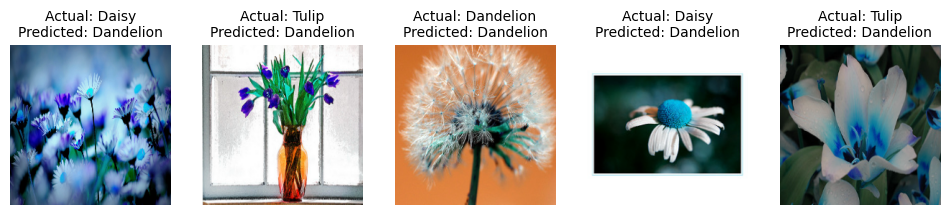

In [52]:
import numpy as np
import pandas as pd
import os
import glob
import cv2
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense

base_path = r"C:\Users\Sanjay A\Desktop\dl\flowers"

print(os.listdir(base_path))

folders = glob.glob(base_path + "/*")

imagenames_list = []
for folder in folders:
    for f in glob.glob(folder + '/*.jpg'):
        imagenames_list.append(f)


def label_img(image):
    word_label = os.path.basename(os.path.dirname(image))
    if word_label == 'daisy':
        return [1,0,0,0,0]
    elif word_label == 'dandelion':
        return [0,1,0,0,0]
    elif word_label == 'rose':
        return [0,0,1,0,0]
    elif word_label == 'tulip':
        return [0,0,0,1,0]
    else:
        return [0,0,0,0,1]

train = []
for image in imagenames_list:
    img = cv2.imread(image)

    if img is None:
        continue

    img = cv2.resize(img, (224,224))
    label = label_img(image)

    train.append([np.array(img), np.array(label)])

np.random.shuffle(train)


print("Total images loaded:", len(train))

X = np.array([i[0] for i in train])
X = X / 255.0
Y = np.array([i[1] for i in train])


model = Sequential()
model.add(VGG16(include_top=False, weights='imagenet', input_shape=(224,224,3)))
model.add(Flatten())
model.add(Dense(512, activation='relu'))
model.add(Dense(5, activation='softmax'))

model.compile(loss='categorical_crossentropy', optimizer='sgd', metrics=['accuracy'])


Fit = model.fit(X, Y, epochs=1, validation_split=0.30)

loss, accuracy = model.evaluate(X, Y)
print(f"Loss: {loss}")
print(f"Accuracy: {accuracy}")

import matplotlib.pyplot as plt

num_images = 5
random_indices = np.random.choice(len(X), num_images, replace=False)

selected_images = X[random_indices]
true_labels = Y[random_indices]

predictions = model.predict(selected_images)
predicted_classes = np.argmax(predictions, axis=1)

flower_names = ['Daisy', 'Dandelion', 'Rose', 'Tulip', 'Sunflower']

plt.figure(figsize=(12,6))
for i in range(num_images):
    plt.subplot(1, num_images, i+1)
    plt.imshow(selected_images[i])
    plt.axis('off')

    actual = flower_names[np.argmax(true_labels[i])]
    predicted = flower_names[predicted_classes[i]]

    plt.title(f"Actual: {actual}\nPredicted: {predicted}", fontsize=10)

plt.show()